In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import mannwhitneyu

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

base = '/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory'
plot_dir = '/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants'

conditions = ['wiii8', 'anosmic', '9047', '23129', '33300']
source_order = ['real', 'pseudo']

condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': "#fead61",
}
pseudo_colour = '#c4c4c4'

real = pd.concat(
    [pd.read_csv(f'{base}/{c}/nearest_neighbour.csv').assign(condition=c, source='real') for c in conditions],
    ignore_index=True,
)

pseudo = pd.concat(
    [pd.read_feather(f'{base}/{c}-pseudo/nearest_neighbour.feather').assign(condition=c, source='pseudo') for c in conditions],
    ignore_index=True,
)

df = pd.concat([real, pseudo], ignore_index=True)

print(df.groupby(['condition', 'source'])['filename'].nunique().unstack()[source_order].loc[conditions])

source     real  pseudo
condition              
wiii8        10     100
anosmic      10     100
9047         10     100
23129        10     100
33300        10     100


In [8]:
# Sanity check: did every recording make it through the parallel run?
check = (
    df.groupby(['condition', 'source'])
      .agg(
          n_dishes=('filename', 'nunique'),
          n_rows=('filename', 'size'),
          n_tracks=('track_id', 'nunique'),
          frames_per_dish=('frame', lambda x: x.nunique()),
          nn_missing_pct=('head_distance', lambda x: 100 * x.isna().mean()),
      )
      .round(1)
)
print(check.loc[conditions])
print()

# Tracks per dish should be 5 everywhere, and no dish should be empty.
tracks_per_dish = df.groupby(['condition', 'source', 'filename'])['track_id'].nunique()
print('tracks per dish:')
print(tracks_per_dish.groupby(['condition', 'source']).value_counts().rename('n_dishes').to_string())
print()

odd = tracks_per_dish[tracks_per_dish != 5]
if len(odd):
    print('DISHES NOT HOLDING 5 TRACKS:')
    print(odd.to_string())
else:
    print('every dish holds 5 tracks')

# Pseudo dishes should never reuse a source recording within themselves.
if 'source_file' in df.columns:
    repeats = (
        df[df['source'] == 'pseudo']
        .groupby(['condition', 'filename'])['source_file']
        .nunique()
    )
    print()
    print('pseudo dishes drawing all 5 larvae from different recordings:',
          f'{(repeats == 5).sum()} of {len(repeats)}')

                  n_dishes   n_rows  n_tracks  frames_per_dish  nn_missing_pct
condition source                                                              
wiii8     pseudo       100  1669373         5             3601             0.0
          real          10   167041         5             3601             0.0
anosmic   pseudo       100  1712007         5             3601             0.0
          real          10   170932         5             3601             0.0
9047      pseudo       100  1719166         5             3600             0.0
          real          10   173392         5             3600             0.0
23129     pseudo       100  1603024         6             3601             0.3
          real          10   159967         6             3601             0.7
33300     pseudo       100  1483030         5             3601             0.5
          real          10   146216         5             3601             0.7

tracks per dish:
condition  source  track_id
23129 

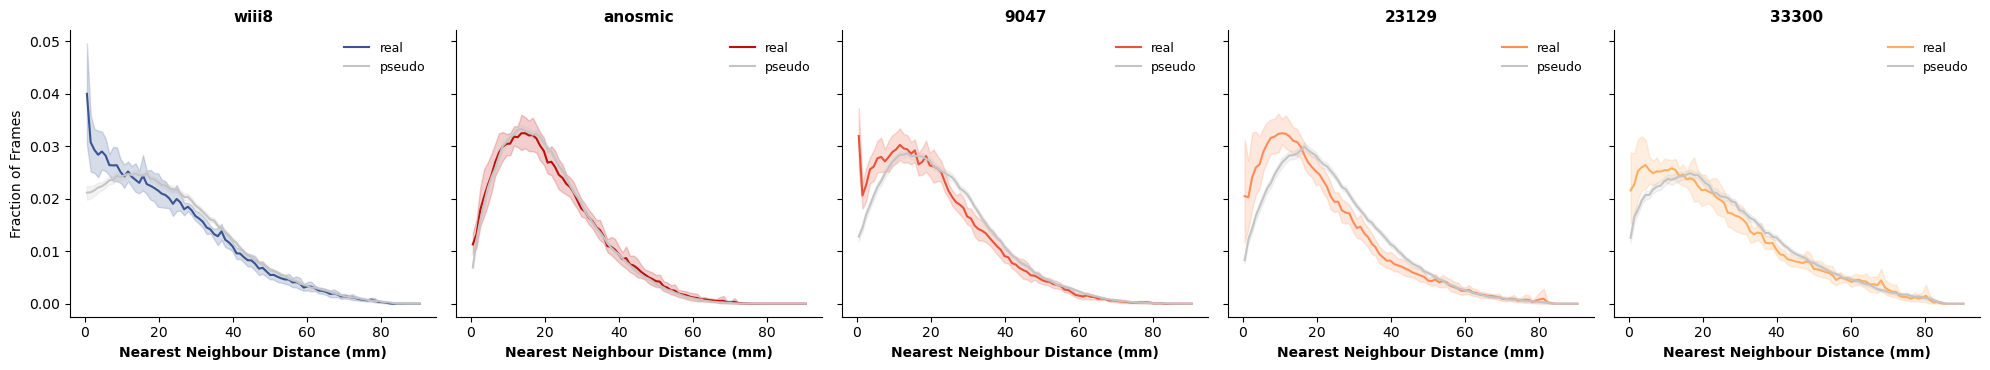

In [9]:
# Nearest neighbour distance distribution: real dishes against their own pseudo null.
bins = np.linspace(0, 91, 91)
df['bin'] = pd.cut(df['head_distance'], bins, include_lowest=True)
df['bin_center'] = df['bin'].apply(lambda x: x.mid)

counts = (
    df.groupby(['filename', 'condition', 'source', 'bin_center'])
    .size()
    .unstack(fill_value=0).stack()
    .groupby(['filename', 'condition', 'source'], group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name='density')
)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.8), sharey=True)

for ax, condition in zip(axes, conditions):

    plot_data = counts[counts['condition'] == condition]

    sns.lineplot(
        data=plot_data, x='bin_center', y='density',
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar=('ci', 95), ax=ax,
    )

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Fraction of Frames' if condition == conditions[0] else '')
    ax.set_xticks(np.arange(0, 91, 20))
    ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_nearest_neighbour_distribution.pdf', format='pdf')
plt.show()

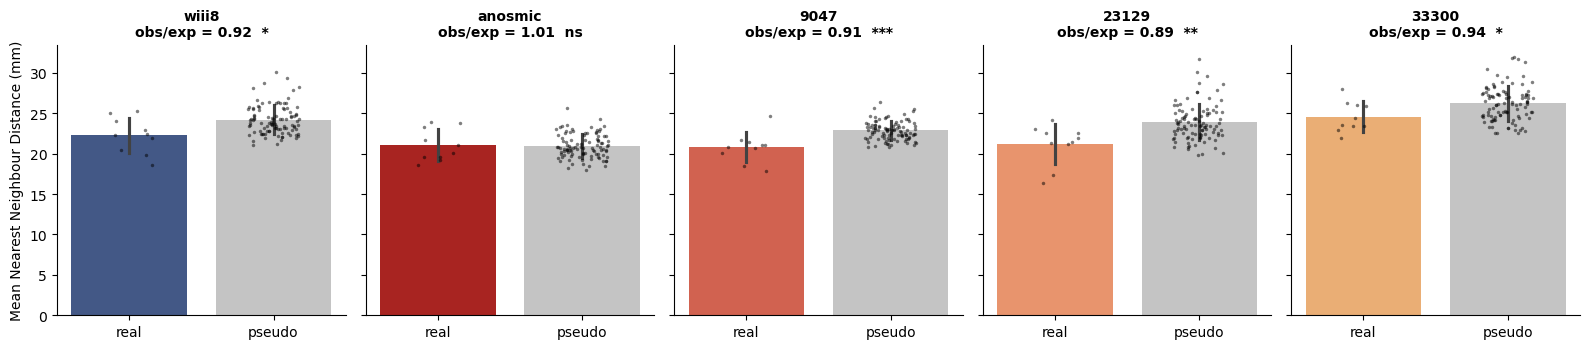

condition  real_mean  pseudo_mean  obs_over_exp     U        p significance
    wiii8  22.290343    24.200683      0.921063 256.0 0.011348            *
  anosmic  21.099317    20.973707      1.005989 499.0 0.995852           ns
     9047  20.794109    22.876956      0.908954 127.0 0.000107          ***
    23129  21.202133    23.881060      0.887822 207.0 0.002356           **
    33300  24.589746    26.218572      0.937875 285.0 0.025730            *


In [10]:
# Mean nearest neighbour distance per dish.
mean_head_distance = (
    df.groupby(['filename', 'condition', 'source'])['head_distance']
      .mean()
      .reset_index(name='mean_head_distance')
      .dropna(subset=['mean_head_distance'])
)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
stats_rows = []

for ax, condition in zip(axes, conditions):

    plot_data = mean_head_distance[mean_head_distance['condition'] == condition]
    real_values = plot_data.loc[plot_data['source'] == 'real', 'mean_head_distance']
    pseudo_values = plot_data.loc[plot_data['source'] == 'pseudo', 'mean_head_distance']

    u_stat, p_value = mannwhitneyu(real_values, pseudo_values, alternative='two-sided')
    ratio = real_values.mean() / pseudo_values.mean()
    stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    stats_rows.append({
        'condition': condition,
        'real_mean': real_values.mean(),
        'pseudo_mean': pseudo_values.mean(),
        'obs_over_exp': ratio,
        'U': u_stat,
        'p': p_value,
        'significance': stars,
    })

    sns.barplot(
        data=plot_data, x='source', y='mean_head_distance', order=source_order,
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar='sd', legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_data, x='source', y='mean_head_distance', order=source_order,
        color='black', size=2.5, jitter=0.18, alpha=0.5, ax=ax,
    )

    ax.set_title(f'{condition}\nobs/exp = {ratio:.2f}  {stars}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean Nearest Neighbour Distance (mm)' if condition == conditions[0] else '')

plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_nearest_neighbour_mean.pdf', format='pdf')
plt.show()

print(pd.DataFrame(stats_rows).to_string(index=False))

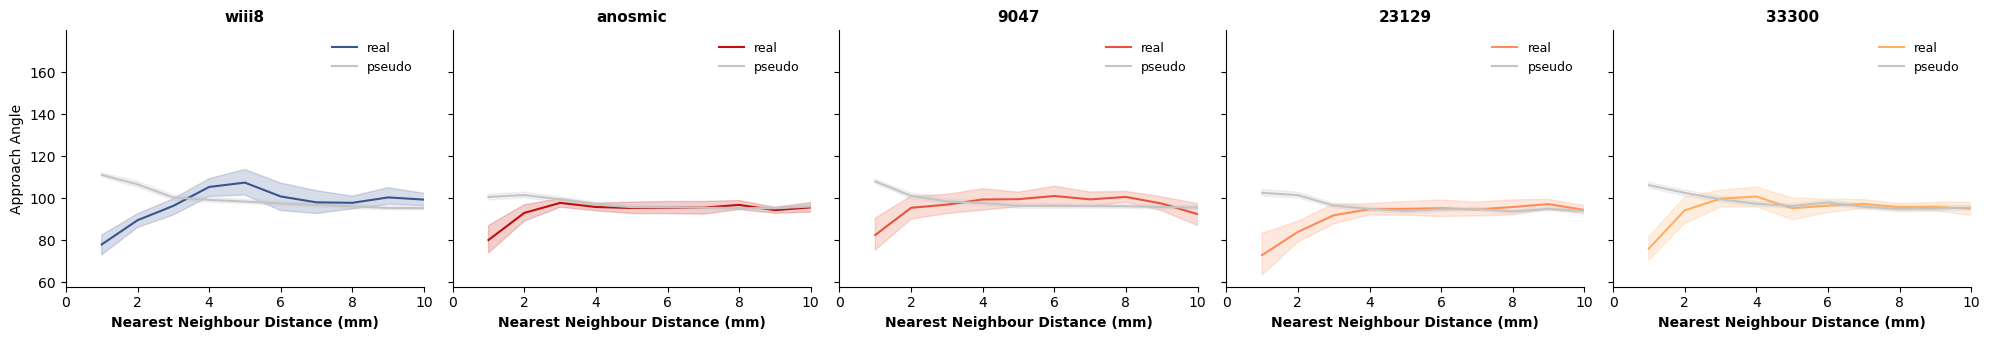

In [11]:
# Approach Angle against nearest neighbour distance, real versus pseudo.
df_binned = df.copy()
df_binned['bin'] = pd.cut(df_binned['head_distance'], list(range(0, 90, 1)), include_lowest=True)
df_binned['bin_right'] = df_binned['bin'].apply(lambda x: x.right).astype(float)

profile = (
    df_binned.groupby(['condition', 'source', 'filename', 'bin_right'], as_index=False)['approach_angle']
      .mean()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), sharey=True)

for ax, condition in zip(axes, conditions):

    plot_data = profile[profile['condition'] == condition]

    sns.lineplot(
        data=plot_data, x='bin_right', y='approach_angle',
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar=('ci', 95), ax=ax,
    )

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Approach Angle' if condition == conditions[0] else '')
    ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_nearest_neighbour_approach_angle.pdf', format='pdf')
plt.show()

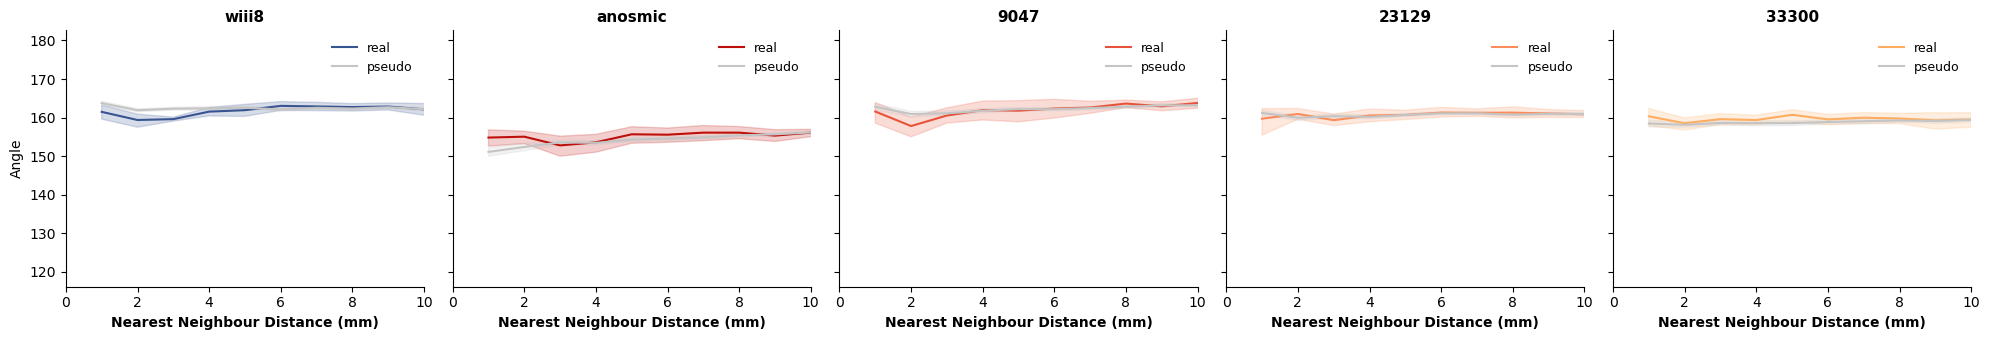

In [12]:
# Angle against nearest neighbour distance, real versus pseudo.
df_binned = df.copy()
df_binned['bin'] = pd.cut(df_binned['head_distance'], list(range(0, 90, 1)), include_lowest=True)
df_binned['bin_right'] = df_binned['bin'].apply(lambda x: x.right).astype(float)

profile = (
    df_binned.groupby(['condition', 'source', 'filename', 'bin_right'], as_index=False)['angle']
      .mean()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), sharey=True)

for ax, condition in zip(axes, conditions):

    plot_data = profile[profile['condition'] == condition]

    sns.lineplot(
        data=plot_data, x='bin_right', y='angle',
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar=('ci', 95), ax=ax,
    )

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Angle' if condition == conditions[0] else '')
    ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_nearest_neighbour_angle.pdf', format='pdf')
plt.show()

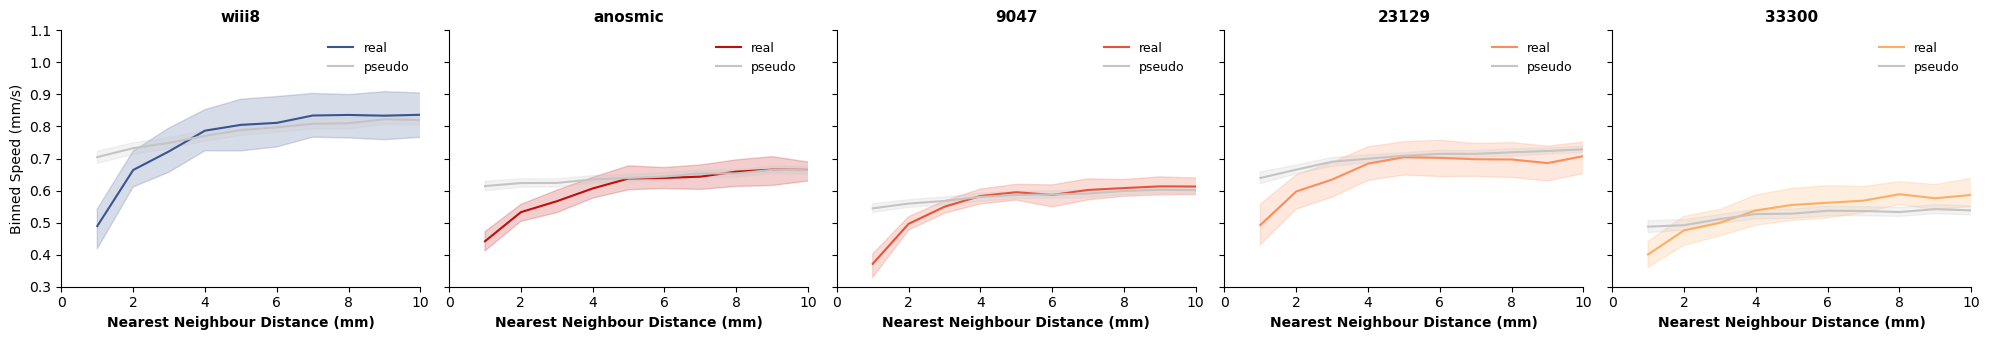

In [13]:
# Binned Speed (mm/s) against nearest neighbour distance, real versus pseudo.
df_binned = df.copy()
df_binned['bin'] = pd.cut(df_binned['head_distance'], list(range(0, 90, 1)), include_lowest=True)
df_binned['bin_right'] = df_binned['bin'].apply(lambda x: x.right).astype(float)

profile = (
    df_binned.groupby(['condition', 'source', 'filename', 'bin_right'], as_index=False)['speed']
      .mean()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), sharey=True)

for ax, condition in zip(axes, conditions):

    plot_data = profile[profile['condition'] == condition]

    sns.lineplot(
        data=plot_data, x='bin_right', y='speed',
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar=('ci', 95), ax=ax,
    )

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_ylim(0.3, 1.1)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Binned Speed (mm/s)' if condition == conditions[0] else '')
    ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_nearest_neighbour_speed.pdf', format='pdf')
plt.show()

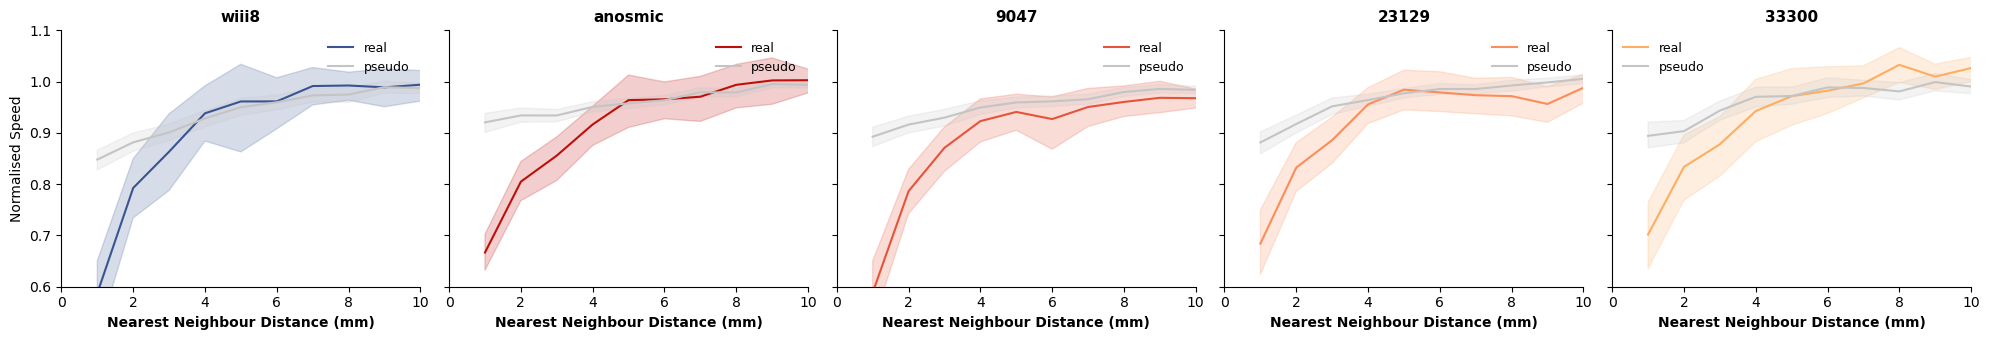

In [14]:
# Speed normalised to each dish's own 10-20 mm baseline (all frames).
df_norm = df.copy()
df_norm['bin'] = pd.cut(df_norm['head_distance'], list(range(0, 90, 1)), include_lowest=True)
df_norm['bin_right'] = df_norm['bin'].apply(lambda x: x.right).astype(float)

baseline = (
    df_norm[(df_norm['bin_right'] >= 10) & (df_norm['bin_right'] < 20)]
      .groupby(['condition', 'source', 'filename'], as_index=False)['speed']
      .mean()
      .rename(columns={'speed': 'mean_speed_10_20'})
)

df_norm = df_norm.merge(baseline, on=['condition', 'source', 'filename'], how='left')
df_norm = df_norm.dropna(subset=['mean_speed_10_20']).copy()
df_norm['speed_norm'] = df_norm['speed'] / df_norm['mean_speed_10_20']

profile = (
    df_norm.groupby(['condition', 'source', 'filename', 'bin_right'], as_index=False)['speed_norm']
      .mean()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), sharey=True)

for ax, condition in zip(axes, conditions):

    plot_data = profile[profile['condition'] == condition]

    sns.lineplot(
        data=plot_data, x='bin_right', y='speed_norm',
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar=('ci', 95), ax=ax,
    )

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_ylim(0.6, 1.1)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Normalised Speed' if condition == conditions[0] else '')
    ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_nearest_neighbour_speed_normalised.pdf', format='pdf')
plt.show()

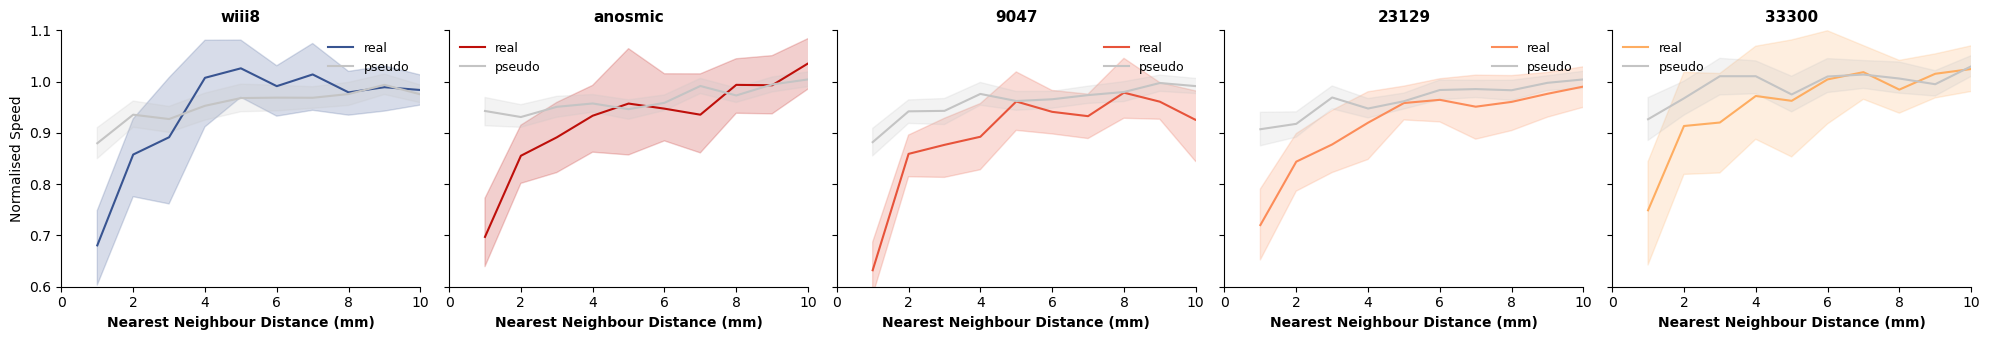

In [15]:
# Speed normalised to each dish's own 10-20 mm baseline (approaching only).
df_norm = df.copy()
df_norm = df_norm[df_norm['approach_angle'] < 35].copy()
df_norm['bin'] = pd.cut(df_norm['head_distance'], list(range(0, 90, 1)), include_lowest=True)
df_norm['bin_right'] = df_norm['bin'].apply(lambda x: x.right).astype(float)

baseline = (
    df_norm[(df_norm['bin_right'] >= 10) & (df_norm['bin_right'] < 20)]
      .groupby(['condition', 'source', 'filename'], as_index=False)['speed']
      .mean()
      .rename(columns={'speed': 'mean_speed_10_20'})
)

df_norm = df_norm.merge(baseline, on=['condition', 'source', 'filename'], how='left')
df_norm = df_norm.dropna(subset=['mean_speed_10_20']).copy()
df_norm['speed_norm'] = df_norm['speed'] / df_norm['mean_speed_10_20']

profile = (
    df_norm.groupby(['condition', 'source', 'filename', 'bin_right'], as_index=False)['speed_norm']
      .mean()
)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), sharey=True)

for ax, condition in zip(axes, conditions):

    plot_data = profile[profile['condition'] == condition]

    sns.lineplot(
        data=plot_data, x='bin_right', y='speed_norm',
        hue='source', hue_order=source_order,
        palette={'real': condition_colors[condition], 'pseudo': pseudo_colour},
        errorbar=('ci', 95), ax=ax,
    )

    ax.set_title(condition, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_ylim(0.6, 1.1)
    ax.set_xlabel('Nearest Neighbour Distance (mm)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Normalised Speed' if condition == conditions[0] else '')
    ax.legend(frameon=False, title=None, fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig(f'{plot_dir}/pseudo_nearest_neighbour_speed_normalised_approaching.pdf', format='pdf')
plt.show()